# Notebook 14 (V4_3) - HKT Scalar Tail Boil-Down Analysis

This notebook is a narrow tail diagnostic for the two-country production economy using the large-bubble `12_v9` calibration. It focuses only on all-`u` paths.

The exercise has two parts:

1. Check whether the two-country tail is approaching a single-country U.S. economy by reporting `e_W/e_US`, `Q_W/Q_US`, `omega_US`, and the recovered U.S. bond share `theta_US` near the end of the solved extended path, including scratch-buffer periods.
2. Replace only the artificial terminal U.S. all-`u` successor `varphi_US,T_solve+1` with the value implied by the single-country HKT scalar equation, then compare the induced full two-country all-`u` path against the existing local-loglinear (`LL`) terminal closure.

`LL` means the model's current local-loglinear terminal successor. `asym` means the terminal-only boiled-down successor rule: U.S. `varphi_{US,T_solve+1}` from the HKT scalar equation and RoW `varphi_{W,T_solve+1}` from local log-linear extrapolation. All solved dates `1:T_solve` remain full two-country production-equilibrium dates.

## 0. Setup

The notebook leaves `TwoCountryProductionOLG.jl` untouched. It overrides `_extrapolate_terminal!` only inside this notebook session, as in Notebook 13.

Use `HKT_SCALAR_TAIL_MODE=smoke` for a short syntax check, `replication` for the certified `12_v9` horizon, and `grid` for a small robustness grid around the baseline.

In [1]:
using Pkg

function find_project_dir(start_dir=pwd())
    dir = start_dir
    while true
        isfile(joinpath(dir, "Project.toml")) && return dir
        parent = dirname(dir)
        parent == dir && return start_dir
        dir = parent
    end
end

const PROJECT_DIR = find_project_dir()
Pkg.activate(PROJECT_DIR)
cd(PROJECT_DIR)

include(joinpath(PROJECT_DIR, "Two_country_production", "TwoCountryProductionOLG.jl"))

using Markdown, Printf, Statistics, LinearAlgebra
using Plots
using Plots.PlotMeasures

gr()
default(size=(940, 560), framestyle=:box, grid=:y, legend=:best,
        linewidth=2, titlefontsize=11, guidefontsize=10,
        tickfontsize=9, legendfontsize=8,
        left_margin=8mm, right_margin=6mm, top_margin=7mm, bottom_margin=8mm)

const OUTDIR = joinpath(PROJECT_DIR, "Two_country_production", "outputs_v43", "hkt_scalar_tail_boil_down")
mkpath(OUTDIR)

const RUN_MODE = Symbol(get(ENV, "HKT_SCALAR_TAIL_MODE", "replication"))
println("RUN_MODE = ", RUN_MODE)
println("OUTDIR   = ", OUTDIR)

  Activating 

RUN_MODE = replication

project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`



OUTDIR   = /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/hkt_scalar_tail_boil_down


## 1. Calibration And Case Grid

The default replication case matches the certified `12_v9` large-bubble calibration: `T_report = 45`, `n_buffer = 5`, `gamma = 0.25`, `pi = 0.80`, `xi_u = 2.0`, `nu_u = 1.5`, `nu_b = 0.5`, `xi_W = 0.5`, `common_world_growth = true`, and `branch_iters = 100`.

In [2]:
const RESID_TOL = 1e-5

function tail_combo_params(; T_max::Int, n_buffer::Int)
    return ProductionParams(T_max=T_max,
        γ=0.25,
        π_persist=0.80,
        ξ_u=2.0,
        ν_u=1.5,
        ν_b=0.5,
        ξ_W=0.5,
        common_world_growth=true,
        branch_iters=100,
        n_buffer=n_buffer,
        do_global_polish=false)
end

if RUN_MODE == :smoke
    CASE_SPECS = [(T_report=5, n_buffer=2)]
    T0_GRID = [2, 4, 5]
    TAIL_REPORT_WINDOW = 3
elseif RUN_MODE == :grid
    CASE_SPECS = [(T_report=45, n_buffer=0),
                  (T_report=45, n_buffer=5),
                  (T_report=45, n_buffer=20),
                  (T_report=60, n_buffer=5)]
    T0_GRID = [20, 30, 40]
    TAIL_REPORT_WINDOW = 8
else
    CASE_SPECS = [(T_report=45, n_buffer=5)]
    T0_GRID = [20, 30, 40, 45]
    TAIL_REPORT_WINDOW = 8
end

TERMINAL_RULES = [:local_loglinear, :hkt_scalar_terminal_us]

println("Case specs: ", CASE_SPECS)
println("T0 grid:    ", T0_GRID)
println("Tail rows:  last ", TAIL_REPORT_WINDOW, " solved periods including buffer")

Case specs: [(T_report = 45, n_buffer = 5)]
T0 grid:    [20, 30, 40, 45]
Tail rows:  last 8 solved periods including buffer


## 2. HKT Scalar Successor Rule

For the U.S. all-`u` successor one step beyond the terminal solved state, the boiled-down rule uses the HKT single-country scalar equation

$$
\frac{1}{aH}
= \varphi - 1 + \beta
+ \frac{\beta(1-\alpha)}{\vartheta\alpha}
\left(\frac{A_X H}{A_L L}\right)^{\rho-1}
\varphi^\rho.
$$

The state dependence enters through the successor U.S. knowledge stock. This scalar equation is used only to set `varphi_US,T_solve+1` inside the terminal closure. The dates `1:T_solve`, including the buffer dates, are still solved by the two-country production system. RoW stays on local log-linear extrapolation, because this scalar equation is the U.S. unbalanced HKT limit, not a RoW terminal condition.

In [3]:
const TAIL_TERMINAL_RULE = Ref(:local_loglinear)
const TAIL_TERMINAL_PARAMS = Ref{Any}(nothing)

phi_clamp(x) = clamp(float(x), 1e-12, 1 - 1e-12)

function local_loglinear_phi(pol::Matrix{Float64}, i::Int, T::Int)
    if T >= 2
        a, b = pol[i, T - 1], pol[i, T]
        if isfinite(a) && isfinite(b) && a > 0 && b > 0
            return phi_clamp(b * b / a)
        end
    end
    return phi_clamp(pol[i, T])
end

function hkt_scalar_phi_us(p::ProductionParams, N_US::Real)
    aH = p.a_US * p.H_US
    B = (p.A_X_US_u * p.H_US * N_US^p.ξ_u) /
        (p.A_L_US_u * p.L_US * N_US^p.ν_u)
    c = (p.β * (1 - p.α_US)) / (p.ϑ_US * p.α_US)
    f(φ) = φ - 1 + p.β + c * B^(p.ρ_US - 1) * φ^p.ρ_US - 1 / aH

    f(1.0) <= 0 && return 1.0

    lo, hi = 1e-14, 1.0
    for _ in 1:240
        mid = 0.5 * (lo + hi)
        f(mid) > 0 ? (hi = mid) : (lo = mid)
    end
    return phi_clamp(0.5 * (lo + hi))
end

function hkt_scalar_successor_phi_us(pol::Matrix{Float64}, T::Int)
    p = TAIL_TERMINAL_PARAMS[]
    p === nothing && return local_loglinear_phi(pol, 1, T)

    # T is the extended solve horizon T_solve = T_report + n_buffer.
    # The scalar HKT equation is used only for the artificial successor
    # varphi_US,T_solve+1. The solved path pol[:, 1:T] remains two-country.
    N_US_path = knowledge_path_US(p, vec(pol[1, 1:T]))
    N_US_succ = N_US_path[T + 1]
    return hkt_scalar_phi_us(p, N_US_succ)
end

# Notebook-local replacement of the model terminal closure. It only writes
# pol[:, T+1]; it never overwrites any solved date in pol[:, 1:T].
function _extrapolate_terminal!(pol::Matrix{Float64}, T::Int)
    pol[:, T + 1] .= pol[:, T]
    rule = TAIL_TERMINAL_RULE[]

    if rule == :local_loglinear
        pol[1, T + 1] = local_loglinear_phi(pol, 1, T)
        pol[2, T + 1] = local_loglinear_phi(pol, 2, T)
    elseif rule == :hkt_scalar_terminal_us
        pol[1, T + 1] = hkt_scalar_successor_phi_us(pol, T)
        pol[2, T + 1] = local_loglinear_phi(pol, 2, T)
    else
        error("Unknown terminal rule: $rule")
    end
    return pol
end

function set_terminal_rule!(rule::Symbol, p::ProductionParams)
    @assert rule in TERMINAL_RULES "unknown terminal rule"
    TAIL_TERMINAL_RULE[] = rule
    TAIL_TERMINAL_PARAMS[] = p
    return rule
end

println("Installed notebook-local HKT scalar terminal closure.")

Installed notebook-local HKT scalar terminal closure.


## 3. Helpers

Each solve is cached by `(T_report, n_buffer, terminal_rule)`. Reported error metrics compare only the reported window `1:T_report`; the boil-down tail table reads the extended solved path, so the last rows include the scratch buffer. The HKT scalar equation appears only through the terminal successor `T_solve+1`, which is reported explicitly in the case summary.

In [4]:
path_vector(result, field::Symbol) = [getfield(s, field) for s in result.u_path]
path_vector_extended(result, field::Symbol) = [getfield(s, field) for s in result.u_path_extended]
positive_for_log(x; floor=1e-300) = max.(Float64.(x), floor)

function pretty(x)
    x === missing && return ""
    x isa Bool && return string(x)
    x isa Integer && return string(x)
    if x isa AbstractFloat
        if !isfinite(x)
            return string(x)
        elseif abs(x) >= 1000 || (abs(x) > 0 && abs(x) < 1e-4)
            return @sprintf("%.3e", x)
        else
            return @sprintf("%.6f", x)
        end
    end
    return string(x)
end

function html_escape(x)
    s = string(x)
    s = replace(s, "&" => "&amp;")
    s = replace(s, "<" => "&lt;")
    s = replace(s, ">" => "&gt;")
    return s
end

function markdown_table(rows, cols; maxrows=length(rows))
    isempty(rows) && return HTML("<p><em>No rows.</em></p>")
    io = IOBuffer()
    print(io, "<div style=\"overflow-x:auto;max-width:100%;\">")
    print(io, "<table style=\"border-collapse:collapse;font-size:90%;line-height:1.25;white-space:nowrap;\">")
    print(io, "<thead><tr>")
    for c in cols
        print(io, "<th style=\"border:1px solid #ddd;padding:4px 6px;text-align:left;\">", html_escape(c), "</th>")
    end
    print(io, "</tr></thead><tbody>")
    for r in rows[1:min(maxrows, length(rows))]
        print(io, "<tr>")
        for c in cols
            print(io, "<td style=\"border:1px solid #ddd;padding:4px 6px;\">", html_escape(pretty(getproperty(r, Symbol(c)))), "</td>")
        end
        print(io, "</tr>")
    end
    print(io, "</tbody></table></div>")
    return HTML(String(take!(io)))
end

function csv_escape(x)
    x === missing && return ""
    s = string(x)
    if occursin(',', s) || occursin('"', s) || occursin('\n', s)
        return "\"" * replace(s, "\"" => "\"\"") * "\""
    end
    return s
end

function write_csv(filename, rows, cols)
    open(filename, "w") do io
        println(io, join(cols, ","))
        for r in rows
            println(io, join([csv_escape(getproperty(r, Symbol(c))) for c in cols], ","))
        end
    end
    return filename
end

function local_loglinear_next_value(x::AbstractVector{<:Real})
    length(x) >= 2 || return phi_clamp(x[end])
    a, b = x[end - 1], x[end]
    if isfinite(a) && isfinite(b) && a > 0 && b > 0
        return phi_clamp(b * b / a)
    end
    return phi_clamp(b)
end

function terminal_successor_N_US(result::ProductionSimulationResult)
    sT = result.u_path_extended[end]
    return G_N_US(result.params, sT.φ_US) * sT.N_US
end

function terminal_successor_phi_US(result::ProductionSimulationResult, rule::Symbol)
    if rule == :local_loglinear
        return local_loglinear_next_value([s.φ_US for s in result.u_path_extended])
    elseif rule == :hkt_scalar_terminal_us
        return hkt_scalar_phi_us(result.params, terminal_successor_N_US(result))
    else
        error("Unknown terminal rule: $rule")
    end
end

function terminal_successor_phi_W(result::ProductionSimulationResult)
    return local_loglinear_next_value([s.φ_W for s in result.u_path_extended])
end

const RESULT_CACHE = Dict{Tuple{Int,Int,Symbol},Any}()

function run_scalar_tail_case(T_report::Int, n_buffer::Int, rule::Symbol; verbose::Bool=false)
    key = (T_report, n_buffer, rule)
    haskey(RESULT_CACHE, key) && return RESULT_CACHE[key]

    p = tail_combo_params(T_max=T_report, n_buffer=n_buffer)
    set_terminal_rule!(rule, p)
    @printf("Solving T_report=%d, n_buffer=%d, rule=%s\n", T_report, n_buffer, String(rule))
    t0 = time()

    try
        result = run_production_simulation(p; verbose=verbose)
        elapsed = time() - t0
        summary = (;
            T_report=T_report,
            n_buffer=n_buffer,
            terminal_rule=String(rule),
            elapsed_sec=elapsed,
            status="ok",
            T_extended=length(result.u_path_extended),
            branch_converged=result.branch_converged,
            max_u_residual=result.max_u_residual,
            max_bgp_residual=result.max_bgp_residual,
            psi_ok=result.diagnostics.psi_ok,
            psi_min=result.diagnostics.psi_min,
            equity_weights_ok=result.diagnostics.equity_weights_ok,
            equity_weight_min=result.diagnostics.equity_weight_min,
            nu_b_effective=result.params.ν_b,
            terminal_successor_scope="T_extended_plus_1_only",
            terminal_successor_N_US=terminal_successor_N_US(result),
            terminal_successor_phi_US=terminal_successor_phi_US(result, rule),
            terminal_successor_phi_W=terminal_successor_phi_W(result),
            phi_US_report_end=result.u_path[end].φ_US,
            phi_US_extended_end=result.u_path_extended[end].φ_US,
            q_US_report_end=result.u_path[end].q_US,
            q_US_extended_end=result.u_path_extended[end].q_US,
            error="")
        out = (; status=:ok, result, summary)
        RESULT_CACHE[key] = out
        return out
    catch err
        elapsed = time() - t0
        summary = (;
            T_report=T_report,
            n_buffer=n_buffer,
            terminal_rule=String(rule),
            elapsed_sec=elapsed,
            status="error",
            T_extended=missing,
            branch_converged=missing,
            max_u_residual=missing,
            max_bgp_residual=missing,
            psi_ok=missing,
            psi_min=missing,
            equity_weights_ok=missing,
            equity_weight_min=missing,
            nu_b_effective=missing,
            terminal_successor_scope="T_extended_plus_1_only",
            terminal_successor_N_US=missing,
            terminal_successor_phi_US=missing,
            terminal_successor_phi_W=missing,
            phi_US_report_end=missing,
            phi_US_extended_end=missing,
            q_US_report_end=missing,
            q_US_extended_end=missing,
            error=sprint(showerror, err))
        out = (; status=:error, result=nothing, summary)
        RESULT_CACHE[key] = out
        @warn "Solve failed" T_report n_buffer rule err
        return out
    end
end

function tail_boil_down_rows(case; last_k::Int=8)
    case.status == :ok || return NamedTuple[]
    result = case.result
    u = result.u_path_extended
    T_report = length(result.u_path)
    T_ext = length(u)
    lo = max(1, T_ext - last_k + 1)
    rows = NamedTuple[]
    for i in lo:T_ext
        s = u[i]
        push!(rows, (;
            T_report=T_report,
            n_buffer=T_ext - T_report,
            terminal_rule=case.summary.terminal_rule,
            solved_t=i,
            is_reported_period=i <= T_report,
            periods_to_extended_end=T_ext - i,
            e_W_over_e_US=s.e_W / s.e_US,
            Q_W_over_Q_US=s.Q_W / s.Q_US,
            omega_US=s.ω,
            theta_US=s.θ,
            theta_US_star=s.θ_US_star,
            phi_US=s.φ_US,
            phi_W=s.φ_W,
            q_US=s.q_US,
            q_W=s.q_W,
            residual_norm=s.residual_norm))
    end
    return rows
end

function max_abs_with_t(values)
    j = argmax(abs.(values))
    return (value=abs(values[j]), t=j)
end

function path_difference_rows(ll_case, asym_case)
    if ll_case.status != :ok || asym_case.status != :ok
        return NamedTuple[]
    end
    T = min(length(ll_case.result.u_path), length(asym_case.result.u_path))
    rows = NamedTuple[]
    q_ll = path_vector(ll_case.result, :q_US)
    q_asym = path_vector(asym_case.result, :q_US)
    phi_ll = path_vector(ll_case.result, :φ_US)
    phi_asym = path_vector(asym_case.result, :φ_US)
    d_ll = path_vector(ll_case.result, :d_US)
    d_asym = path_vector(asym_case.result, :d_US)
    for t in 1:T
        push!(rows, (;
            T_report=ll_case.summary.T_report,
            n_buffer=ll_case.summary.n_buffer,
            t=t,
            log_q_diff=log(q_ll[t]) - log(q_asym[t]),
            abs_log_q_diff=abs(log(q_ll[t]) - log(q_asym[t])),
            log_phi_diff=log(phi_ll[t]) - log(phi_asym[t]),
            abs_log_phi_diff=abs(log(phi_ll[t]) - log(phi_asym[t])),
            log_dividend_yield_diff=log(d_ll[t] / q_ll[t]) - log(d_asym[t] / q_asym[t]),
            abs_log_dividend_yield_diff=abs(log(d_ll[t] / q_ll[t]) - log(d_asym[t] / q_asym[t])),
            phi_LL=phi_ll[t],
            phi_asym=phi_asym[t],
            q_LL=q_ll[t],
            q_asym=q_asym[t]))
    end
    return rows
end

function path_difference_metric_row(ll_case, asym_case, T0::Int)
    if ll_case.status != :ok || asym_case.status != :ok
        return (T_report=ll_case.summary.T_report,
                n_buffer=ll_case.summary.n_buffer,
                T0=T0,
                status="error",
                max_log_q_diff=missing,
                t_max_log_q_diff=missing,
                max_log_phi_diff=missing,
                t_max_log_phi_diff=missing,
                max_log_dividend_yield_diff=missing,
                t_max_log_dividend_yield_diff=missing,
                max_u_residual_LL=ll_case.summary.max_u_residual,
                max_u_residual_asym=asym_case.summary.max_u_residual)
    end

    T = min(T0, length(ll_case.result.u_path), length(asym_case.result.u_path))
    q_ll = path_vector(ll_case.result, :q_US)[1:T]
    q_asym = path_vector(asym_case.result, :q_US)[1:T]
    phi_ll = path_vector(ll_case.result, :φ_US)[1:T]
    phi_asym = path_vector(asym_case.result, :φ_US)[1:T]
    d_ll = path_vector(ll_case.result, :d_US)[1:T]
    d_asym = path_vector(asym_case.result, :d_US)[1:T]

    log_q = log.(positive_for_log(q_ll)) .- log.(positive_for_log(q_asym))
    log_phi = log.(positive_for_log(phi_ll)) .- log.(positive_for_log(phi_asym))
    log_dq = log.(positive_for_log(d_ll ./ q_ll)) .- log.(positive_for_log(d_asym ./ q_asym))
    mq = max_abs_with_t(log_q)
    mp = max_abs_with_t(log_phi)
    mdq = max_abs_with_t(log_dq)

    return (;
        T_report=ll_case.summary.T_report,
        n_buffer=ll_case.summary.n_buffer,
        T0=T0,
        status="ok",
        max_log_q_diff=mq.value,
        t_max_log_q_diff=mq.t,
        max_log_phi_diff=mp.value,
        t_max_log_phi_diff=mp.t,
        max_log_dividend_yield_diff=mdq.value,
        t_max_log_dividend_yield_diff=mdq.t,
        max_u_residual_LL=ll_case.summary.max_u_residual,
        max_u_residual_asym=asym_case.summary.max_u_residual)
end

path_difference_metric_row (generic function with 1 method)

## 4. Run LL And HKT-Scalar Tail Cases

The same calibration is solved twice for each case: first with the existing local-loglinear terminal successor, then with the terminal-only U.S. HKT scalar successor.

In [5]:
case_pairs = NamedTuple[]
for spec in CASE_SPECS
    ll = run_scalar_tail_case(spec.T_report, spec.n_buffer, :local_loglinear)
    asym = run_scalar_tail_case(spec.T_report, spec.n_buffer, :hkt_scalar_terminal_us)
    push!(case_pairs, (; spec..., LL=ll, asym=asym))
end

summary_rows = [c.summary for pair in case_pairs for c in (pair.LL, pair.asym)]
summary_cols = ["T_report", "n_buffer", "terminal_rule", "elapsed_sec", "status",
                "T_extended", "branch_converged", "max_u_residual", "max_bgp_residual",
                "psi_ok", "psi_min", "equity_weights_ok", "equity_weight_min",
                "nu_b_effective", "terminal_successor_scope",
                "terminal_successor_N_US", "terminal_successor_phi_US",
                "terminal_successor_phi_W", "phi_US_report_end", "phi_US_extended_end",
                "q_US_report_end", "q_US_extended_end", "error"]
write_csv(joinpath(OUTDIR, "case_summary.csv"), summary_rows, summary_cols)

markdown_table(summary_rows,
    ["T_report", "n_buffer", "terminal_rule", "status", "T_extended",
     "max_u_residual", "max_bgp_residual", "terminal_successor_phi_US",
     "phi_US_extended_end", "q_US_extended_end"];
    maxrows=length(summary_rows))

Solving T_report=45, n_buffer=5, rule=local_loglinear
Solving T_report=45, n_buffer=5, rule=hkt_scalar_terminal_us


T_report,n_buffer,terminal_rule,status,T_extended,max_u_residual,max_bgp_residual,terminal_successor_phi_US,phi_US_extended_end,q_US_extended_end
45,5,local_loglinear,ok,50,8.512e-06,7.029e-10,0.220058,0.228534,8.846936
45,5,hkt_scalar_terminal_us,ok,50,4.048e-08,7.024e-10,0.211918,0.222837,9.292281


## 5. End-Of-Buffer Boil-Down Diagnostics

These rows use the extended solved path, not only the reported path. The final row for each case is the end of the scratch-buffer solve, which is where the terminal closure directly bites.

In [6]:
tail_rows = reduce(vcat, [tail_boil_down_rows(c; last_k=TAIL_REPORT_WINDOW)
                          for pair in case_pairs for c in (pair.LL, pair.asym)]; init=NamedTuple[])

tail_cols = ["T_report", "n_buffer", "terminal_rule", "solved_t", "is_reported_period",
             "periods_to_extended_end", "e_W_over_e_US", "Q_W_over_Q_US",
             "omega_US", "theta_US", "theta_US_star", "phi_US", "phi_W",
             "q_US", "q_W", "residual_norm"]
write_csv(joinpath(OUTDIR, "end_of_buffer_boil_down_diagnostics.csv"), tail_rows, tail_cols)

markdown_table(tail_rows,
    ["T_report", "n_buffer", "terminal_rule", "solved_t", "periods_to_extended_end",
     "e_W_over_e_US", "Q_W_over_Q_US", "omega_US", "theta_US",
     "phi_US", "q_US", "residual_norm"];
    maxrows=length(tail_rows))

T_report,n_buffer,terminal_rule,solved_t,periods_to_extended_end,e_W_over_e_US,Q_W_over_Q_US,omega_US,theta_US,phi_US,q_US,residual_norm
45,5,local_loglinear,43,7,0.024559,0.150592,0.879222,-0.002780,0.296181,5.168252,7.122e-06
45,5,local_loglinear,44,6,0.021871,0.138602,0.887296,-0.002319,0.285659,5.571576,7.805e-06
45,5,local_loglinear,45,5,0.019458,0.127366,0.895071,-0.001933,0.275418,6.010219,8.512e-06
45,5,local_loglinear,46,4,0.017298,0.116873,0.902520,-0.001612,0.265465,6.487150,9.243e-06
45,5,local_loglinear,47,3,0.015368,0.107106,0.909623,-0.001344,0.255800,7.005601,9.993e-06
45,5,local_loglinear,48,2,0.013645,0.098044,0.916364,-0.001121,0.246424,7.569094,1.076e-05
45,5,local_loglinear,49,1,0.012111,0.089662,0.922731,-0.000936,0.237336,8.181473,1.154e-05
45,5,local_loglinear,50,0,0.010746,0.081932,0.928718,-0.000782,0.228534,8.846936,0.000666
45,5,hkt_scalar_terminal_us,43,7,0.022871,0.116777,0.904117,-0.002557,0.291191,5.340427,3.463e-08
45,5,hkt_scalar_terminal_us,44,6,0.020060,0.102742,0.914309,-0.002090,0.280474,5.772151,3.754e-08


## 6. LL Versus HKT-Scalar Path Differences

The metric table reports the requested quantities over reported windows:

$$
\max_{t \le T_{report}}\left|\log q_{US,t}^{LL}-\log q_{US,t}^{asym}\right|,
\qquad
\max_{t \le T_{report}}\left|\log \varphi_{US,t}^{LL}-\log \varphi_{US,t}^{asym}\right|.
$$

The table also includes `d/q` as a price-dividend diagnostic.

In [7]:
metric_rows = NamedTuple[]
for pair in case_pairs
    for T0 in T0_GRID
        push!(metric_rows, path_difference_metric_row(pair.LL, pair.asym, T0))
    end
    push!(metric_rows, path_difference_metric_row(pair.LL, pair.asym, pair.T_report))
end
metric_rows = unique(metric_rows)

metric_cols = ["T_report", "n_buffer", "T0", "status", "max_log_q_diff",
               "t_max_log_q_diff", "max_log_phi_diff", "t_max_log_phi_diff",
               "max_log_dividend_yield_diff", "t_max_log_dividend_yield_diff",
               "max_u_residual_LL", "max_u_residual_asym"]
write_csv(joinpath(OUTDIR, "ll_vs_hkt_scalar_path_difference_metrics.csv"), metric_rows, metric_cols)

path_diff_rows = reduce(vcat, [path_difference_rows(pair.LL, pair.asym) for pair in case_pairs]; init=NamedTuple[])
path_diff_cols = ["T_report", "n_buffer", "t", "log_q_diff", "abs_log_q_diff",
                  "log_phi_diff", "abs_log_phi_diff", "log_dividend_yield_diff",
                  "abs_log_dividend_yield_diff", "phi_LL", "phi_asym", "q_LL", "q_asym"]
write_csv(joinpath(OUTDIR, "ll_vs_hkt_scalar_path_differences.csv"), path_diff_rows, path_diff_cols)

markdown_table(metric_rows,
    ["T_report", "n_buffer", "T0", "max_log_q_diff", "t_max_log_q_diff",
     "max_log_phi_diff", "t_max_log_phi_diff", "max_log_dividend_yield_diff",
     "max_u_residual_LL", "max_u_residual_asym"];
    maxrows=length(metric_rows))

T_report,n_buffer,T0,max_log_q_diff,t_max_log_q_diff,max_log_phi_diff,t_max_log_phi_diff,max_log_dividend_yield_diff,max_u_residual_LL,max_u_residual_asym
45,5,20,0.000811,20,0.000435,20,0.000435,8.512e-06,4.048e-08
45,5,30,0.006519,30,0.003440,30,0.003440,8.512e-06,4.048e-08
45,5,40,0.025068,40,0.013050,40,0.013050,8.512e-06,4.048e-08
45,5,45,0.037927,45,0.019617,45,0.019617,8.512e-06,4.048e-08


## 7. Plots

The first plot shows the tail boil-down diagnostics on the extended LL path. The second plot shows absolute LL-versus-HKT-scalar differences on the reported path.

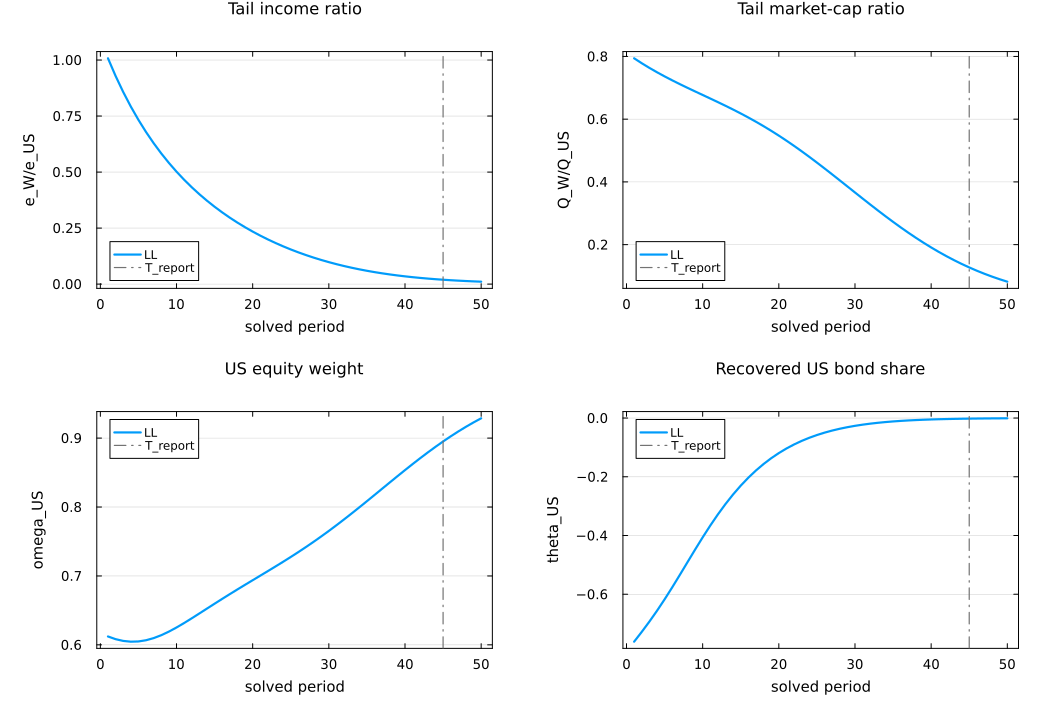

In [8]:
plot_pair = first(case_pairs)
ll_plot = plot_pair.LL
asym_plot = plot_pair.asym

if ll_plot.status == :ok
    u = ll_plot.result.u_path_extended
    tt_ext = 1:length(u)
    T_report_plot = length(ll_plot.result.u_path)

    p_e = plot(tt_ext, [s.e_W / s.e_US for s in u], lw=2.2, label="LL",
               xlabel="solved period", ylabel="e_W/e_US", title="Tail income ratio")
    p_Q = plot(tt_ext, [s.Q_W / s.Q_US for s in u], lw=2.2, label="LL",
               xlabel="solved period", ylabel="Q_W/Q_US", title="Tail market-cap ratio")
    p_w = plot(tt_ext, [s.ω for s in u], lw=2.2, label="LL",
               xlabel="solved period", ylabel="omega_US", title="US equity weight")
    p_th = plot(tt_ext, [s.θ for s in u], lw=2.2, label="LL",
                xlabel="solved period", ylabel="theta_US", title="Recovered US bond share")

    for pfig in (p_e, p_Q, p_w, p_th)
        vline!(pfig, [T_report_plot], lc=:gray45, ls=:dashdot, lw=1.2, label="T_report")
    end

    fig_tail = plot(p_e, p_Q, p_w, p_th, layout=(2, 2), size=(1050, 720), bottom_margin=7mm)
    savefig(fig_tail, joinpath(OUTDIR, "ll_end_of_buffer_boil_down_diagnostics.png"))
    fig_tail
else
    Markdown.parse("_LL plot case failed._")
end

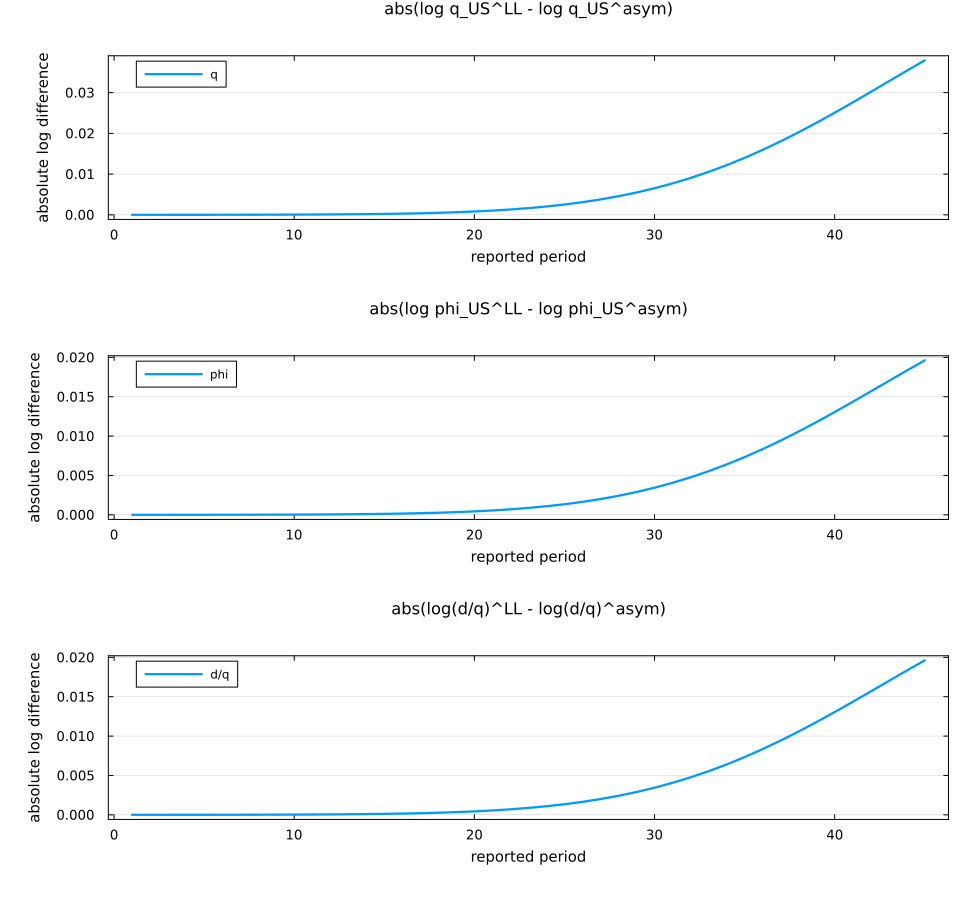

In [9]:
if ll_plot.status == :ok && asym_plot.status == :ok
    rows = path_difference_rows(ll_plot, asym_plot)
    tt = [r.t for r in rows]
    p_qdiff = plot(tt, [r.abs_log_q_diff for r in rows], lw=2.3,
                   xlabel="reported period", ylabel="absolute log difference",
                   title="abs(log q_US^LL - log q_US^asym)", label="q")
    p_phidiff = plot(tt, [r.abs_log_phi_diff for r in rows], lw=2.3,
                     xlabel="reported period", ylabel="absolute log difference",
                     title="abs(log phi_US^LL - log phi_US^asym)", label="phi")
    p_dqdiff = plot(tt, [r.abs_log_dividend_yield_diff for r in rows], lw=2.3,
                    xlabel="reported period", ylabel="absolute log difference",
                    title="abs(log(d/q)^LL - log(d/q)^asym)", label="d/q")
    fig_diff = plot(p_qdiff, p_phidiff, p_dqdiff, layout=(3, 1), size=(980, 900), bottom_margin=7mm)
    savefig(fig_diff, joinpath(OUTDIR, "ll_vs_hkt_scalar_path_differences.png"))
    fig_diff
else
    Markdown.parse("_Path-difference plot case failed._")
end

## 8. Output Files

The generated files are:

- `case_summary.csv`
- `end_of_buffer_boil_down_diagnostics.csv`
- `ll_vs_hkt_scalar_path_difference_metrics.csv`
- `ll_vs_hkt_scalar_path_differences.csv`
- `ll_end_of_buffer_boil_down_diagnostics.png`
- `ll_vs_hkt_scalar_path_differences.png`

In [10]:
println("Saved output files in:")
println("  ", OUTDIR)
for f in sort(readdir(OUTDIR))
    println("  ", joinpath(OUTDIR, f))
end

Saved output files in:
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/hkt_scalar_tail_boil_down
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/hkt_scalar_tail_boil_down/case_summary.csv
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/hkt_scalar_tail_boil_down/end_of_buffer_boil_down_diagnostics.csv
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/hkt_scalar_tail_boil_down/ll_end_of_buffer_boil_down_diagnostics.png
  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/hkt_scalar_tail_boil_down/ll_vs_hkt_scalar_path_difference_metrics.csv
  /Users/jipengcheng/Library/Mob